## Setup for LSTM

In [62]:
#pip install --upgrade pip
#%pip install keras
#%pip install tensorflow 

In [63]:
#%pip install keras

In [64]:
 #%pip install tensorflow 

In [65]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# this for time series
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
#from scipy.ndimage import gaussian_filter
#from calendar import monthrange
#from calendar import month_name
#from sklearn.metrics import mean_squared_error
#from math import sqrt
#from statsmodels.tsa.stattools import adfuller,kpss
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.arima_model import ARIMA
#from statsmodels.graphics.tsaplots import plot_pacf
#from pmdarima.arima import auto_arima
#import statsmodels.graphics.tsaplots as tsaplot
#from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#import tensorflow as tf
#from keras.models import Sequential
#from keras.layers import LSTM, Dense

#from keras.optimizers import Adam
#from keras.callbacks import EarlyStopping

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
#from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.regularizers import L1L2
import time
import matplotlib.dates as mdates   

#from tensorflow.keras.wrappers.scikit_learn import KerasRegressor  # Correct import
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


m#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [66]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [67]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [68]:
#res_df.dtypes

In [69]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [70]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [71]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [72]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [73]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [74]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [75]:
data_df_gwh = data_df_mwh.copy()

In [76]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [77]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [78]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [79]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [80]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [81]:

data_df= data_df_gwh.copy()

In [82]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [83]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [84]:
##data_df.columns

In [85]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [86]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files

#main_0  = 'Total_energy_generation_gwh' # This is only for energy
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy

main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', 'energy generation (GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy in GWh
Solarenergy generation (GWh)


### Here we set the function for line plot  

In [87]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



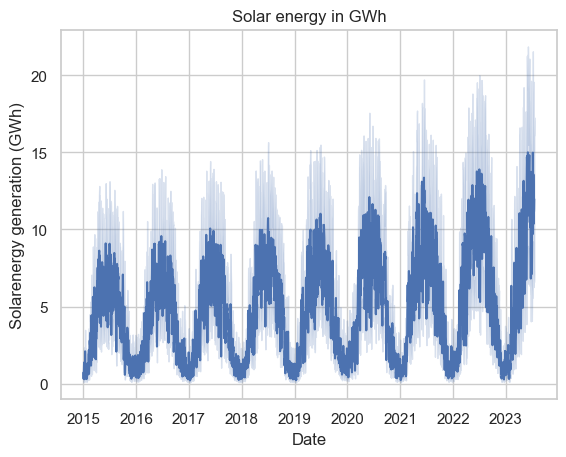

In [88]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [89]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [90]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [91]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

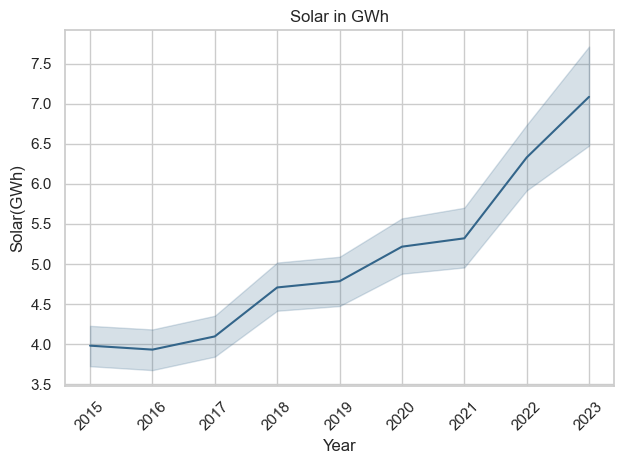

In [92]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [93]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [94]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Solar_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,0.00000
2015-01-01,2015,1,1,1,1,0.00000
2015-01-01,2015,1,1,1,2,0.00000
2015-01-01,2015,1,1,1,3,0.00000
2015-01-01,2015,1,1,1,4,0.00000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,10.08425
2023-07-17,2023,7,17,198,19,4.72400
2023-07-17,2023,7,17,198,20,1.51125


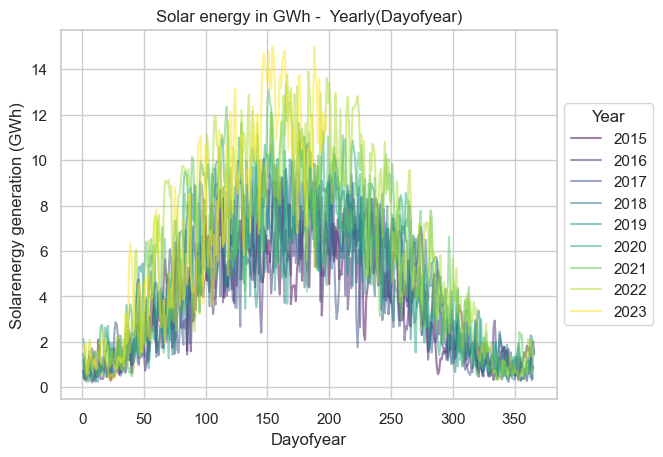

In [95]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [96]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [97]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_29252/3941561451.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df[target])


Text(0.5, 1.0, 'Energy Distribution')

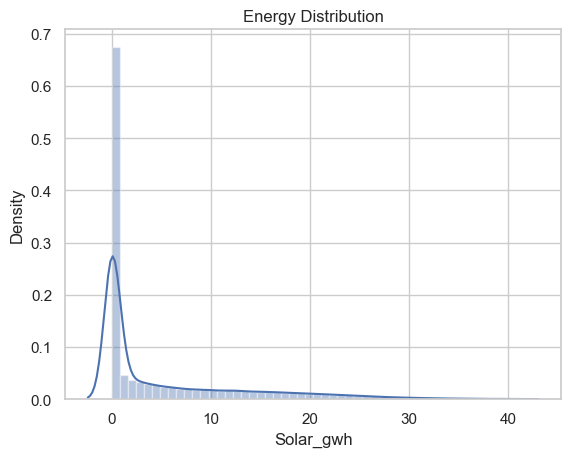

In [98]:
sns.distplot(data_df[target])
plt.title("Energy Distribution")

In [99]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [100]:
df_c = data_df.copy()

In [101]:
df_dt_hour = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)

In [102]:
df_dt_hour.head()

,Datetime,Solar_gwh
0,2015-01-01 00:00:00,0.0
1,2015-01-01 01:00:00,0.0
2,2015-01-01 02:00:00,0.0
3,2015-01-01 03:00:00,0.0
4,2015-01-01 04:00:00,0.0


In [103]:
df_dt_hour.columns

Index(['Datetime', 'Solar_gwh'], dtype='object')

In [104]:
#df_dt_hour = df_dt_hour.set_index('Datetime')
#df_dt_hour.plot(style = '-', figsize = (15,5), color='#1f76b4')

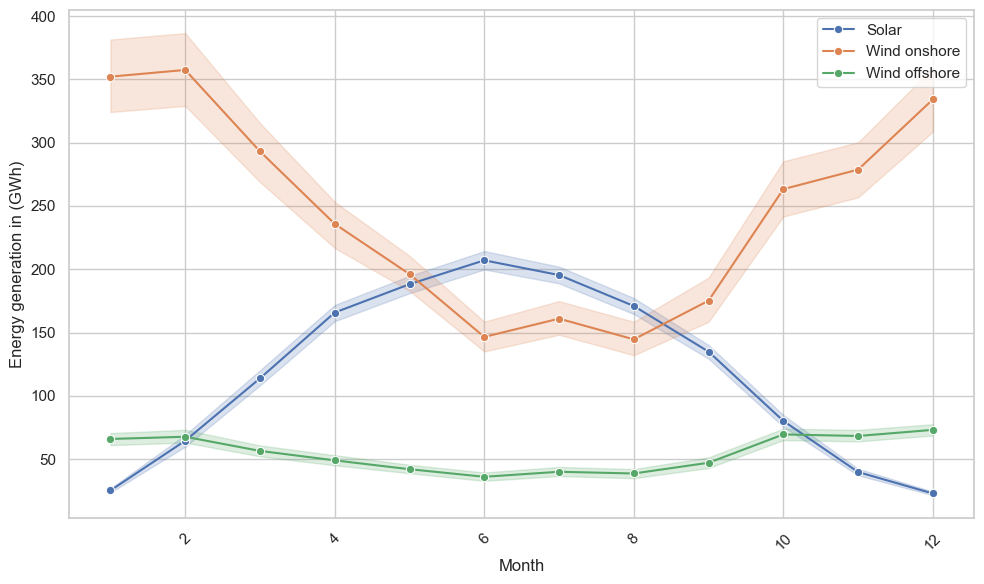

In [105]:
def average_lineplot(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

def simple_lineplot(df, y_values, x='Date', time=' '):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Weather conditions')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

average_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')   
#average_lineplot(df=data_df, y_values=['Total_energy_generation_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')

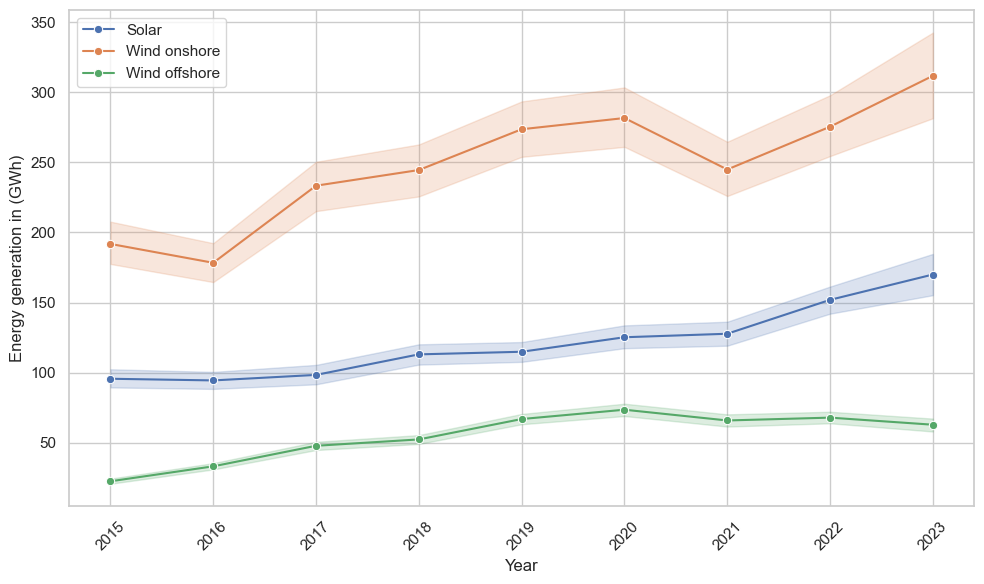

In [106]:
def average_lineplot_no_group(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])

    plt.show()

average_lineplot_no_group(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Year')   
#average_lineplot_no_group(df=data_df, y_values=['Total_energy_generation_gwh', 'Total_other_renewable_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot_no_group(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')

### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

In [107]:
# Split data into train and test set
#window=365#*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
#

#df_arima = data_df[target]
#train_test_split_ratio = int(len(df_arima)*0.8)
#train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(train_data, 'red', label='Train data')
#plt.plot(test_data, 'black', label='Test data')
#plt.legend()
#plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

In [108]:
df_c = data_df.copy()

In [109]:
def combine_date_and_time(df, date_column='Date', time_column='Hour', target_column=target):
    # Convert 'Date' column to datetime format
    df['Date'] = pd.to_datetime(df['Date'])
    
    # Combine 'Date' and 'Hour' columns to create the 'Datetime' column
    df['Datetime'] = df.apply(lambda row: row[date_column] + pd.Timedelta(hours=row[time_column]), axis=1)
    
    # Select the desired columns for the final DataFrame
    df_result  = df[['Datetime', target_column]]
    
    return df_result

In [110]:
dfs = data_df[['Date',  target]]

In [111]:
#print(dfs.shape)
#plt.figure()
#plt.plot(dfs['Date'], dfs[target])
#plt.autoscale(enable=True, axis='x', tight=True)
#plt.show();

In [112]:
df_dt = combine_date_and_time(df_c, date_column='Date', time_column='Hour', target_column=target)
df_dt.head()

,Datetime,Solar_gwh
0,2015-01-01 00:00:00,0.0
1,2015-01-01 01:00:00,0.0
2,2015-01-01 02:00:00,0.0
3,2015-01-01 03:00:00,0.0
4,2015-01-01 04:00:00,0.0


<Axes: xlabel='Datetime'>

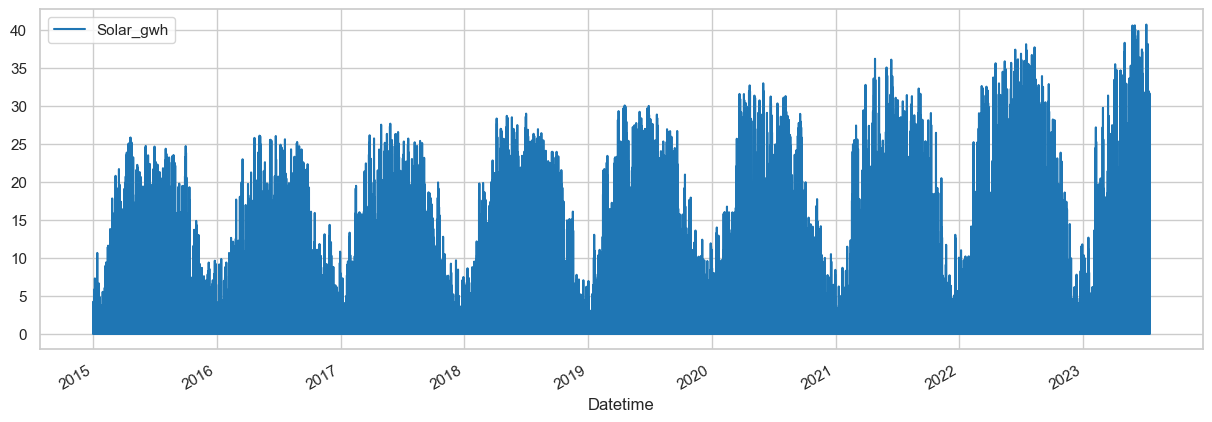

In [113]:
df_dt = df_dt.set_index('Datetime')
df_dt.plot(style = '-', figsize = (15,5), color='#1f76b4')

In [114]:
def create_features(df):
    """
    create time series features based on time series index 
    """
    df['Hour'] = df.index.hour
    df['Year'] = df.index.year
    df['Month'] = df.index.month
    df['Day'] = df.index.day
    df['Dayofyear'] = df.index.dayofyear
    return df

### Feature creations

In [115]:
features=['Date'] #['Hour','Year', 'Month', 'Day', 'Dayofyear']

In [116]:
#train = create_features(train)
#test = create_features(test)
#train.head()
# Select the necessary columns 'Date' and the target column 'target'
dfs = data_df[['Date', target]]

In [117]:
dfs = data_df[['Date', target]]

In [61]:
dfs.head()

NameError: name 'dfs' is not defined

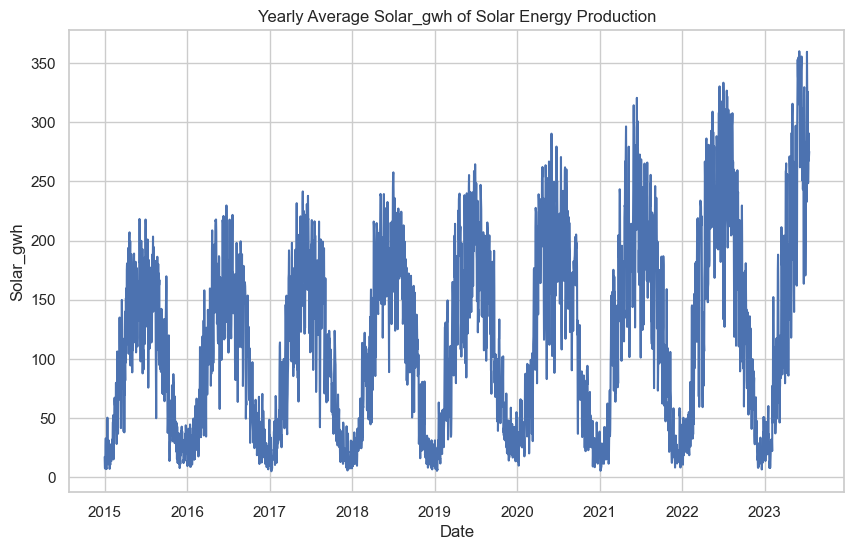

In [42]:
def plot_yearly_average_solar(target, data_df, y_values, x='Date', time='Year'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year) and calculate the average
    grouped_df = data_df.groupby([x, time], as_index=False) \
                        .agg({y_values: np.sum}) \
                        .set_index(x)
    
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=grouped_df, x=grouped_df.index, y=y_values)
    
    # Customize labels and title
    plt.xlabel(x)
    plt.ylabel(y_values)
    plt.title(f"Yearly Average {y_values} of Solar Energy Production")
    
    # Show the plot
    plt.show()
plot_yearly_average_solar(target='Solar_gwh', data_df=data_df, y_values='Solar_gwh', x='Date', time='Year')
# Example usage
#plot_yearly_average_solar(target='Solar_gwh', data_df=data_df, y_values='Solar_gwh')


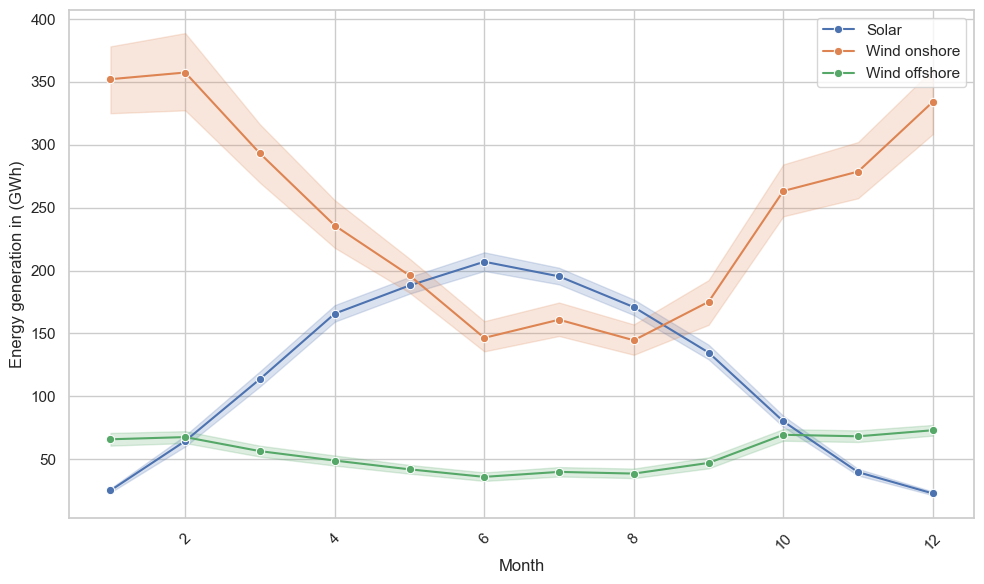

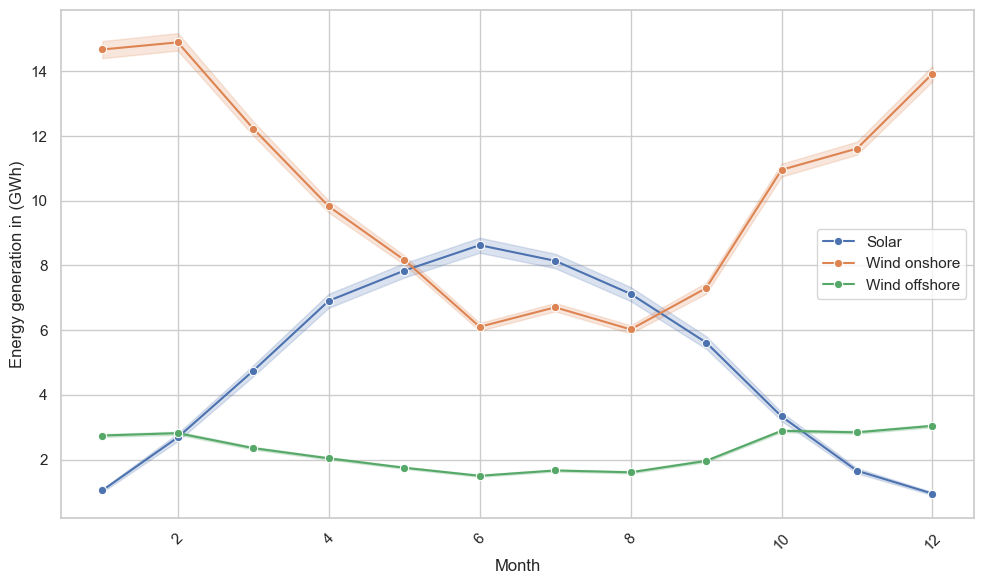

In [53]:
def average_lineplot(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

def simple_lineplot(df, y_values, x='Date', time=' '):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df #\
        #    .groupby([x, time], as_index=False) \
        #    .agg({y: np.sum}) \
        #    .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

average_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')   
#average_lineplot(df=data_df, y_values=['Total_energy_generation_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')


simple_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month') 
#simple_lineplot(df=data_df, y_values=['Mean_air_temperature_de_c',
#        'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm',
#        'Spot_market_price_eur_per_gwh',
#        'Co2_emission_allowances_auction_eur_per_tco2'], x="Date", time='Month')   

            Year  Solar_gwh
Date                       
2015-01-01  2015   17.08025
2015-01-02  2015    7.75900
2015-01-03  2015    7.23475
2015-01-04  2015   19.98250
2015-01-05  2015   26.52225
...          ...        ...
2023-07-13  2023  261.14500
2023-07-14  2023  290.87575
2023-07-15  2023  267.57125
2023-07-16  2023  271.85500
2023-07-17  2023  275.28375

[3120 rows x 2 columns] (3120, 2)                Area                   Mtu  Biomass_gwh  Fossil_brown_coal_gwh  \
0      Germany (DE)  20150101 00:00-01:00      3.99750               15.68725   
1      Germany (DE)  20150101 01:00-02:00      3.95650               15.32175   
2      Germany (DE)  20150101 02:00-03:00      3.99175               14.81750   
3      Germany (DE)  20150101 03:00-04:00      4.00975               14.07500   
4      Germany (DE)  20150101 04:00-05:00      4.00600               14.11500   
...             ...                   ...          ...                    ...   
74874  Germany (DE)  20230717 18:0

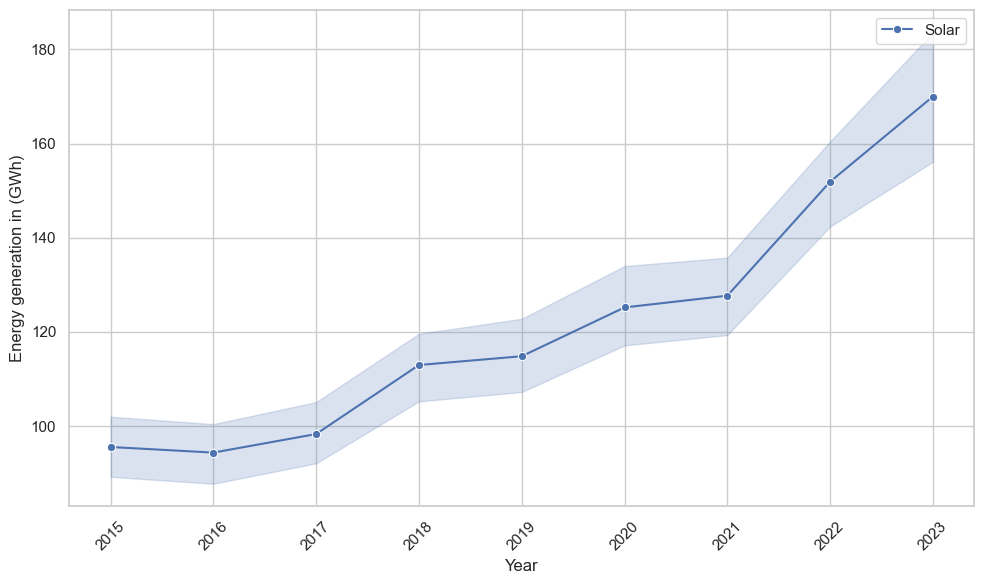

In [140]:
def average_lineplot(df, y_values, x='Date', time='Year'):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df \
            .groupby([x, time], as_index=False) \
            .agg({y: np.sum}) \
            .set_index(x)
        print(grouped_df,  grouped_df.shape, df, df.shape)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

def simple_lineplot(df, y_values, x='Date', time=' '):
    fig, ax = plt.subplots(figsize=(10, 6))

    for y in y_values:
        grouped_df = df #\
        #    .groupby([x, time], as_index=False) \
        #    .agg({y: np.sum}) \
        #    .set_index(x)

        y_label_00 = y.replace('_gwh', ' (GWh)')
        y_label_target0 = y_label_00.replace('_', ' ')

        sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, label=y_label_target0, marker='o')

    ax.set(title='', ylabel='Energy generation in (GWh)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()

    # Remove '(GWh)' from the legend labels
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=[label.replace(' (GWh)', '') for label in labels])
    plt.show()

average_lineplot(df=data_df, y_values=['Solar_gwh'], x="Date", time='Year')   
#
#
#average_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month') 
#average_lineplot(df=data_df, y_values=['Total_energy_generation_gwh', 'Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')
#average_lineplot(df=data_df, y_values=['Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month')


#simple_lineplot(df=data_df, y_values=['Solar_gwh', 'Wind_onshore_gwh', 'Wind_offshore_gwh'], x="Date", time='Month') 
#
#
#simple_lineplot(df=data_df, y_values=['Mean_air_temperature_de_c',
#        'Mean_sunshine_duration_de_minute', 'Mean_precipitation_de_mm',
#        'Spot_market_price_eur_per_gwh',
#        'Co2_emission_allowances_auction_eur_per_tco2'], x="Date", time='Month')   

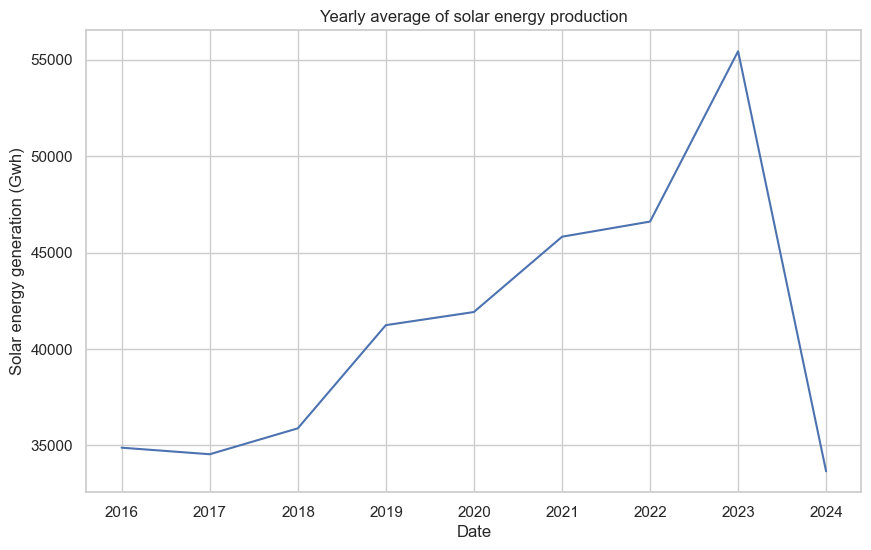

In [57]:
def plot_yearly_average(target, data_df, y_values, x='Date', time='Year'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year)
    grouped = data_df.groupby(pd.Grouper(key='Date', freq='Y'))[target].sum().reset_index()
    
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=grouped, x=x, y=y_values)
    
    # Customize labels and title
    plt.xlabel(x)
    plt.ylabel('Solar energy generation (Gwh)')
    plt.title(f"Yearly average of solar energy production")
    
    # Show the plot
    plt.show()

plot_yearly_average(target='Solar_gwh', data_df=data_df, y_values='Solar_gwh', x='Date', time='Year')
# Example usage
#plot_yearly_average_solar(target='Solar_gwh', data_df=data_df, y_values='Solar_gwh')


        Date    Solar_gwh
0 2015-12-31  34879.41800
1 2016-12-31  34538.93625
2 2017-12-31  35883.18100
3 2018-12-31  41234.28300
4 2019-12-31  41914.77025
5 2020-12-31  45821.57800
6 2021-12-31  46606.88475
7 2022-12-31  55440.97500
8 2023-12-31  33656.71425 (9, 2)


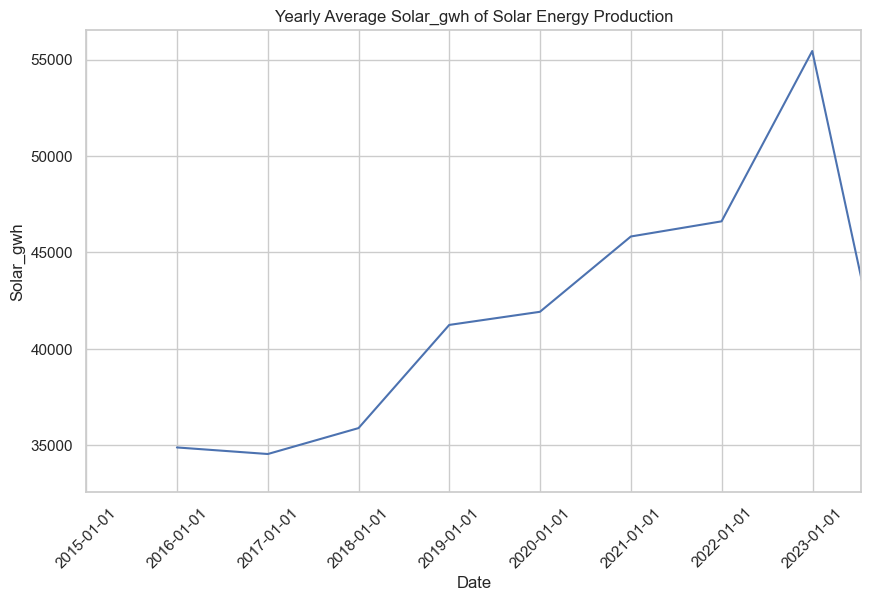

In [136]:

def plot_yearly_average(target, data_df, y_values, x='Date', time='Year'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year)
    grouped = data_df.groupby(pd.Grouper(key='Date', freq='Y'))[target].sum().reset_index()
    
    print(grouped, grouped.shape)
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(data=grouped, x=x, y=y_values)
    
    # Customize labels and title
    plt.xlabel(x)
    plt.ylabel(y_values)
    plt.title(f"Yearly Average {y_values} of Solar Energy Production")
    
    # Set x-axis date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
    
    # Set x-axis limits based on data range
    plt.xlim(data_df['Date'].min(), data_df['Date'].max())
    
    # Show the plot
    plt.show()

# Example usage
plot_yearly_average(target='Solar_gwh', data_df=data_df, y_values='Solar_gwh', x='Date', time='Year')


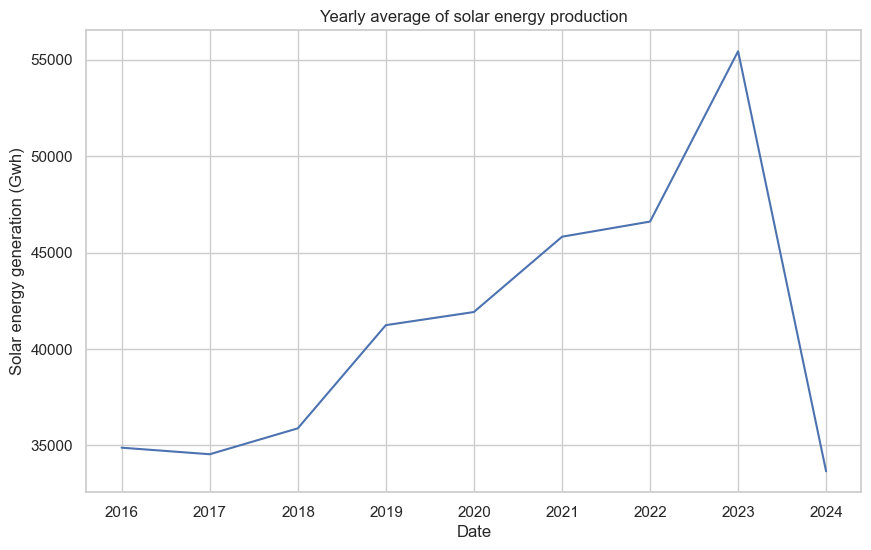

In [135]:
def plot_yearly_average(target, data_df, y_values, x='Date', time='Year'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year)
    grouped = data_df.groupby(pd.Grouper(key='Date', freq='Y'))[target].sum().reset_index()
    
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=grouped, x=x, y=y_values)
    
    # Customize labels and title
    plt.xlabel(x)
    plt.ylabel('Solar energy generation (Gwh)')
    plt.title(f"Yearly average of solar energy production")
    
    # Show the plot
    plt.show()

plot_yearly_average(target='Solar_gwh', data_df=data_df, y_values='Solar_gwh', x='Date', time='Month')
# Example usage
#plot_yearly_average_solar(target='Solar_gwh', data_df=data_df, y_values='Solar_gwh')


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_29252/52667186.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_df['Date'] = pd.to_datetime(data_df['Date'])


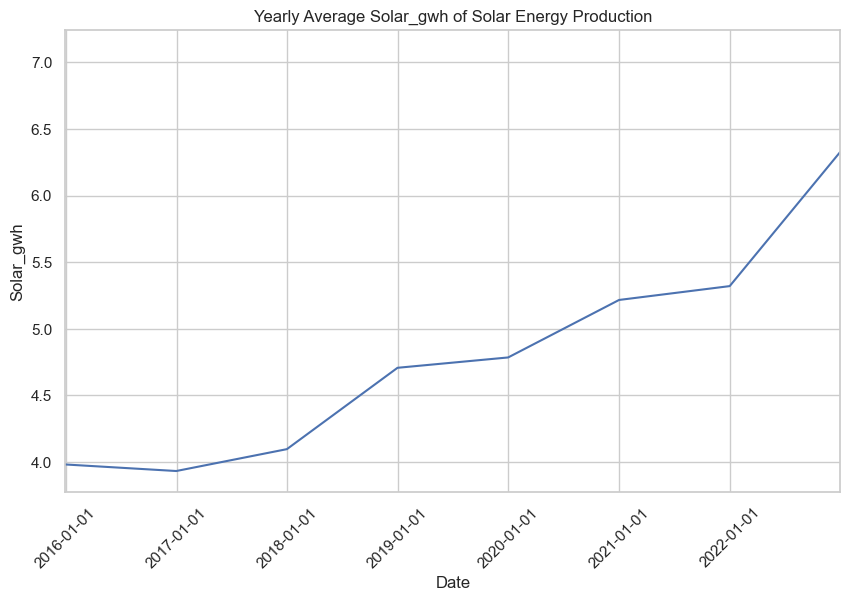

In [137]:

def plot_yearly_average(target, data_df, y_values, x='Date', time='Year'):
    # Convert the 'Date' column to datetime
    data_df['Date'] = pd.to_datetime(data_df['Date'])
    
    # Group data by the specified time interval (Year)
    grouped = data_df.groupby(pd.Grouper(key='Date', freq='Y'))[target].mean().reset_index()
    
    # Set plot style
    sns.set(style="whitegrid")
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    ax = sns.lineplot(data=grouped, x=x, y=y_values)
    
    # Customize labels and title
    plt.xlabel(x)
    plt.ylabel(y_values)
    plt.title(f"Yearly Average {y_values} of Solar Energy Production")
    
    # Set x-axis date formatting
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
    
    # Set x-axis limits based on data range
    start_date = pd.Timestamp('2015-12-31')
    end_date = pd.Timestamp('2022-12-31')
    plt.xlim(start_date, end_date)
    
    # Show the plot
    plt.show()

# Example usage
plot_yearly_average(target='Solar_gwh', data_df=dfs, y_values='Solar_gwh', x='Date', time='Year')
